In [59]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input, Dense, Reshape, Conv1DTranspose, BatchNormalization, Conv1D, LeakyReLU, Flatten, Lambda
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.losses import mse
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras import backend as K

In [60]:
import numpy as np

# Load
X_all = np.load('EEG_all_epochs.npy')

print("Original shape:", X_all.shape)

# Normalize per sample (VERY important for VAE)
X_all = (X_all - X_all.mean(axis=1, keepdims=True)) / \
        (X_all.std(axis=1, keepdims=True) + 1e-8)




print("Final shape:", X_all.shape)

Original shape: (4514, 512)
Final shape: (4514, 512)


In [61]:
# 80:20 training-validation split
X_train, X_test = train_test_split(X_all,  test_size=0.2)

In [62]:
import tensorflow as tf
from tensorflow.keras import layers

# 1. Define the class (Stable across all Python versions)
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 2. In your Encoder definition, replace the Lambda line with this:
# z = Lambda(sampling, name='z')([z_mean, z_log_var]) <-- REMOVE THIS
z = Sampling(name='z')([z_mean, z_log_var]) # ADD THIS LINE

In [63]:
# VAE model
input_shape = (512, 1)
batch_size = 32
latent_dim = 16   # was 2 → too small
epochs = 1000

# reparameterization
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=K.shape(z_mean))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon


# ======================
# Encoder
# ======================

inputs = Input(shape=input_shape, name='encoder_input')
x = inputs

# Block 1
x = Conv1D(32, kernel_size=25, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.2)(x)

# Block 2
x = Conv1D(64, kernel_size=25, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.2)(x)

# Block 3
x = Conv1D(128, kernel_size=15, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.2)(x)

shape_before_flatten = K.int_shape(x)

x = Flatten()(x)
x = Dense(64, activation='relu')(x)

z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)

# Change the name to something fresh like 'z_sampling_new'
z = Sampling(name='z_sampling_new')([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 512, 1)]     0           []                               
                                                                                                  
 conv1d_30 (Conv1D)             (None, 256, 32)      832         ['encoder_input[0][0]']          
                                                                                                  
 batch_normalization_30 (BatchN  (None, 256, 32)     128         ['conv1d_30[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 leaky_re_lu_18 (LeakyReLU)     (None, 256, 32)      0           ['batch_normalization_30[0]

In [64]:
from keras.layers import UpSampling1D

# ======================
# Decoder
# ======================

latent_inputs = Input(shape=(latent_dim,), name='z_sampling')

# Expand back to conv shape
x = Dense(shape_before_flatten[1] * shape_before_flatten[2],
          activation='relu')(latent_inputs)

x = Reshape((shape_before_flatten[1],
             shape_before_flatten[2]))(x)

# Block 1
x = UpSampling1D(size=2)(x)
x = Conv1D(128, 15, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

# Block 2
x = UpSampling1D(size=2)(x)
x = Conv1D(64, 25, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

# Block 3
x = UpSampling1D(size=2)(x)
x = Conv1D(32, 25, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

# Final output layer
outputs = Conv1D(1, 3, padding='same', name='decoder_output')(x)

decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_sampling (InputLayer)     [(None, 16)]              0         
                                                                 
 dense_11 (Dense)            (None, 8192)              139264    
                                                                 
 reshape_4 (Reshape)         (None, 64, 128)           0         
                                                                 
 up_sampling1d_12 (UpSamplin  (None, 128, 128)         0         
 g1D)                                                            
                                                                 
 conv1d_33 (Conv1D)          (None, 128, 128)          245888    
                                                                 
 batch_normalization_33 (Bat  (None, 128, 128)         512       
 chNormalization)                                          

In [65]:
# VAE model (merging encoder and decoder)
outputs = decoder(encoder(inputs)[2])
vae = Model(inputs, outputs, name='vae')
vae.summary()

Model: "vae"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_input (InputLayer)  [(None, 512, 1)]          0         
                                                                 
 encoder (Functional)        [(None, 16),              702432    
                              (None, 16),                        
                              (None, 16)]                        
                                                                 
 decoder (Functional)        (None, 512, 1)            642241    
                                                                 
Total params: 1,344,673
Trainable params: 1,343,777
Non-trainable params: 896
_________________________________________________________________


In [66]:
reconstruction_loss = mse(K.flatten(inputs), K.flatten(outputs))
reconstruction_loss *= np.prod(input_shape)

# KL Divergence loss
kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
kl_loss = K.sum(kl_loss, axis=-1)
kl_loss *= -0.5

# Total loss
vae_loss = K.mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)

# Optimizer and Compile
optimizer = Adam(learning_rate=0.001, beta_1=0.5, beta_2=0.999)
vae.compile(optimizer=optimizer)

vae.summary()

Model: "vae"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 512, 1)]     0           []                               
                                                                                                  
 encoder (Functional)           [(None, 16),         702432      ['encoder_input[0][0]']          
                                 (None, 16),                                                      
                                 (None, 16)]                                                      
                                                                                                  
 decoder (Functional)           (None, 512, 1)       642241      ['encoder[0][2]']                
                                                                                                

In [67]:
# early stopping callback
callbacks = EarlyStopping(monitor = 'val_loss',
                          mode='min',
                          patience =50,
                          verbose = 1,
                          restore_best_weights = True)

In [68]:
# # fit vae model
# history = vae.fit(X_train,X_train,
#             epochs=1000,
#             batch_size=32,
#             validation_data=(X_test, X_test),callbacks=callbacks)

In [69]:
# # Modern Keras 3 / TF 2.x standard
# vae.save('my_eeg_vae.keras')

In [83]:
vae.load_weights('my_eeg_vae.keras')
print("Weights loaded successfully!")

Weights loaded successfully!


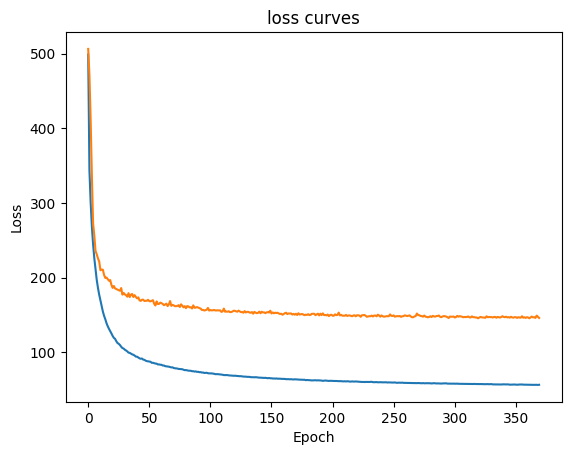

In [84]:
# loss curves
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss curves')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

29/29 [==============================] - 0s 7ms/step


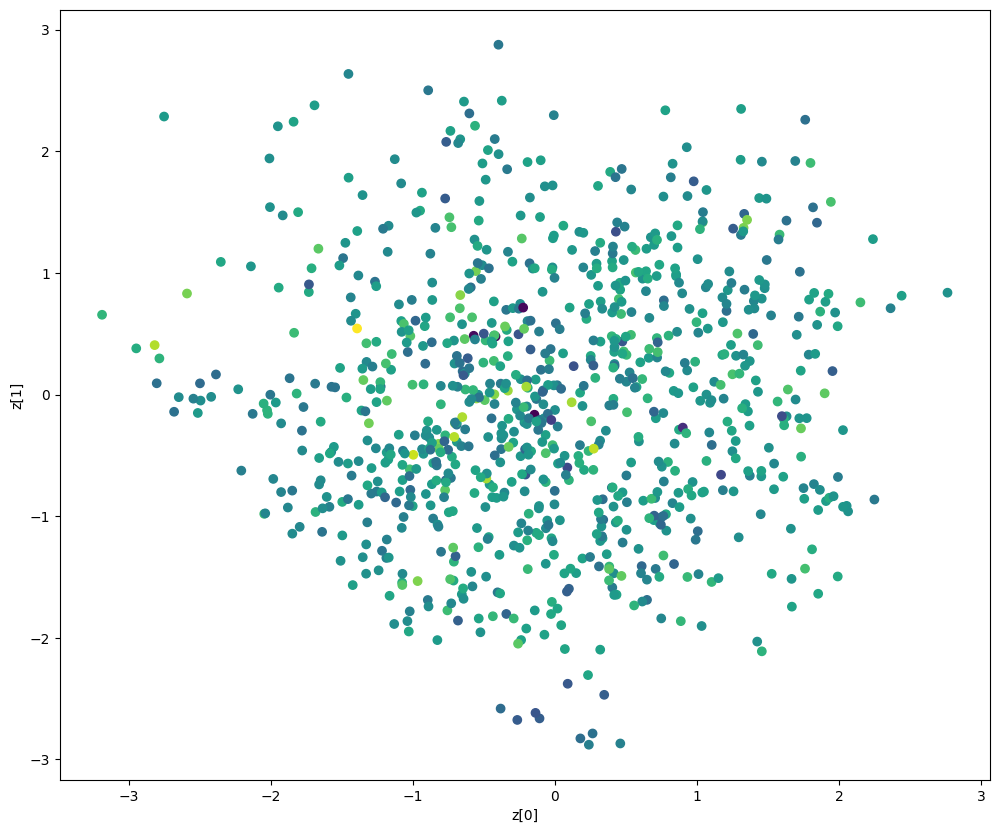

In [85]:
# 2D plot of the classes in latent space
z_m, _, _ = encoder.predict(X_test,batch_size=batch_size)
plt.figure(figsize=(12, 10))
plt.scatter(z_m[:, 0], z_m[:, 1], c=X_test[:,0])
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.show()

In [88]:
# predicting on validation data
pred=vae.predict(X_test)

29/29 [==============================] - 0s 15ms/step


1/1 [==============================] - 0s 317ms/step


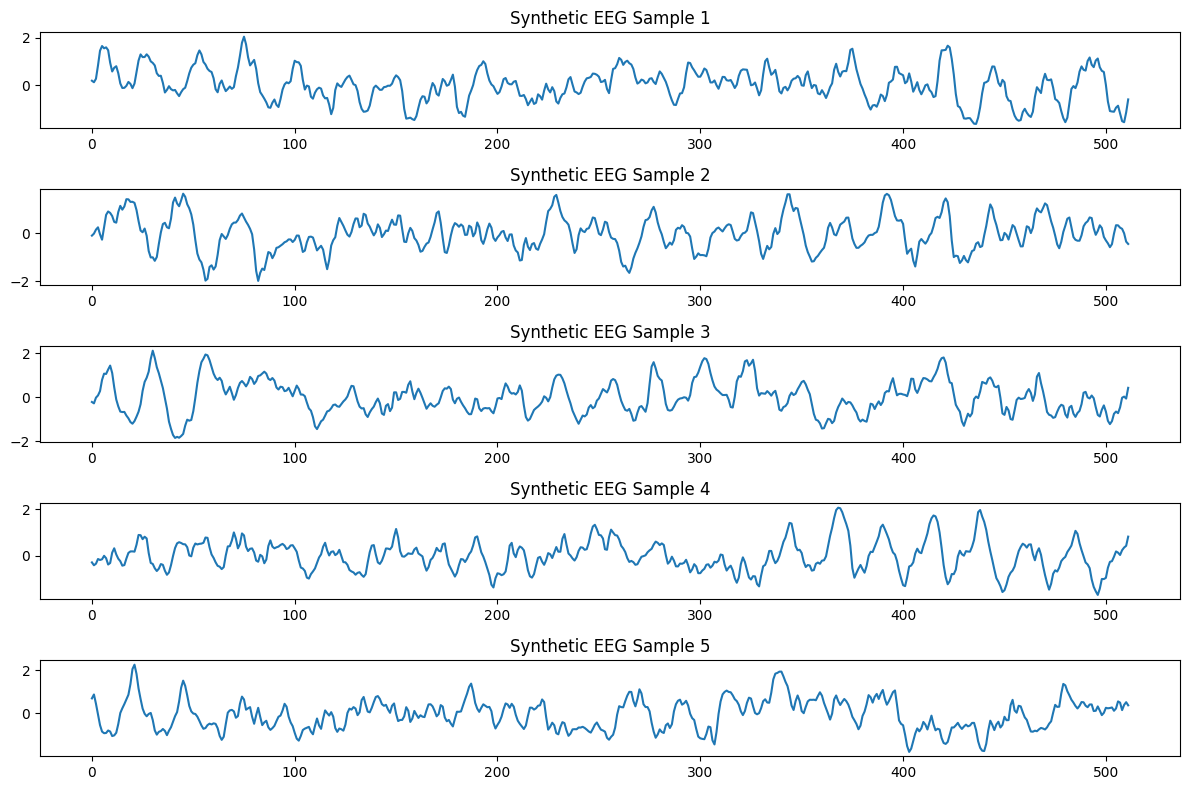

In [90]:
import numpy as np
import matplotlib.pyplot as plt

def generate_synthetic_eeg(decoder_model, num_samples=10, latent_dim=16):
    # 1. Generate random vectors from a standard normal distribution
    # This represents picking random points in your learned 'brain' space
    random_latent_vectors = np.random.normal(size=(num_samples, latent_dim))
    
    # 2. Use the decoder to turn these vectors into EEG signals
    synthetic_signals = decoder_model.predict(random_latent_vectors)
    
    # 3. Reshape for plotting (remove the last channel dimension if it's (Samples, 512, 1))
    synthetic_signals = synthetic_signals.reshape(num_samples, 512)
    
    return synthetic_signals

# Generate 5 new signals
new_signals = generate_synthetic_eeg(decoder, num_samples=5, latent_dim=16)

# Plotting the results
plt.figure(figsize=(12, 8))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(new_signals[i])
    plt.title(f"Synthetic EEG Sample {i+1}")
plt.tight_layout()
plt.show()

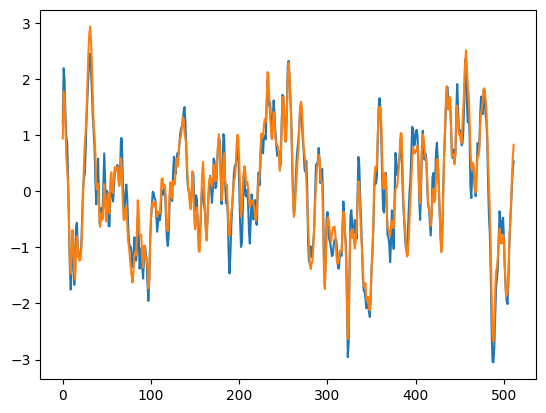

In [89]:
# observing generated signals
plt.plot(X_test[0,:])
plt.plot(pred[0,:])

In [92]:
import pywt
import pandas as pd
import numpy as np

def extract_dwt_features(signals, wavelet='db4', level=4):
    """
    Applies DWT to signals and extracts statistical features 
    consistent with your baseline multichannel notebook.
    """
    features = []
    for signal in signals:
        # Perform DWT decomposition
        coeffs = pywt.wavedec(signal, wavelet, level=level)
        
        # In your pipeline, you calculate statistics for each coefficient level
        # (Approx and Details) representing different frequency bands
        signal_features = []
        for coeff in coeffs:
            signal_features.extend([
                np.mean(coeff),
                np.std(coeff),
                np.var(coeff),
                float(pd.Series(coeff).skew()),
                float(pd.Series(coeff).kurt())
            ])
        features.append(signal_features)
        
    return np.array(features)

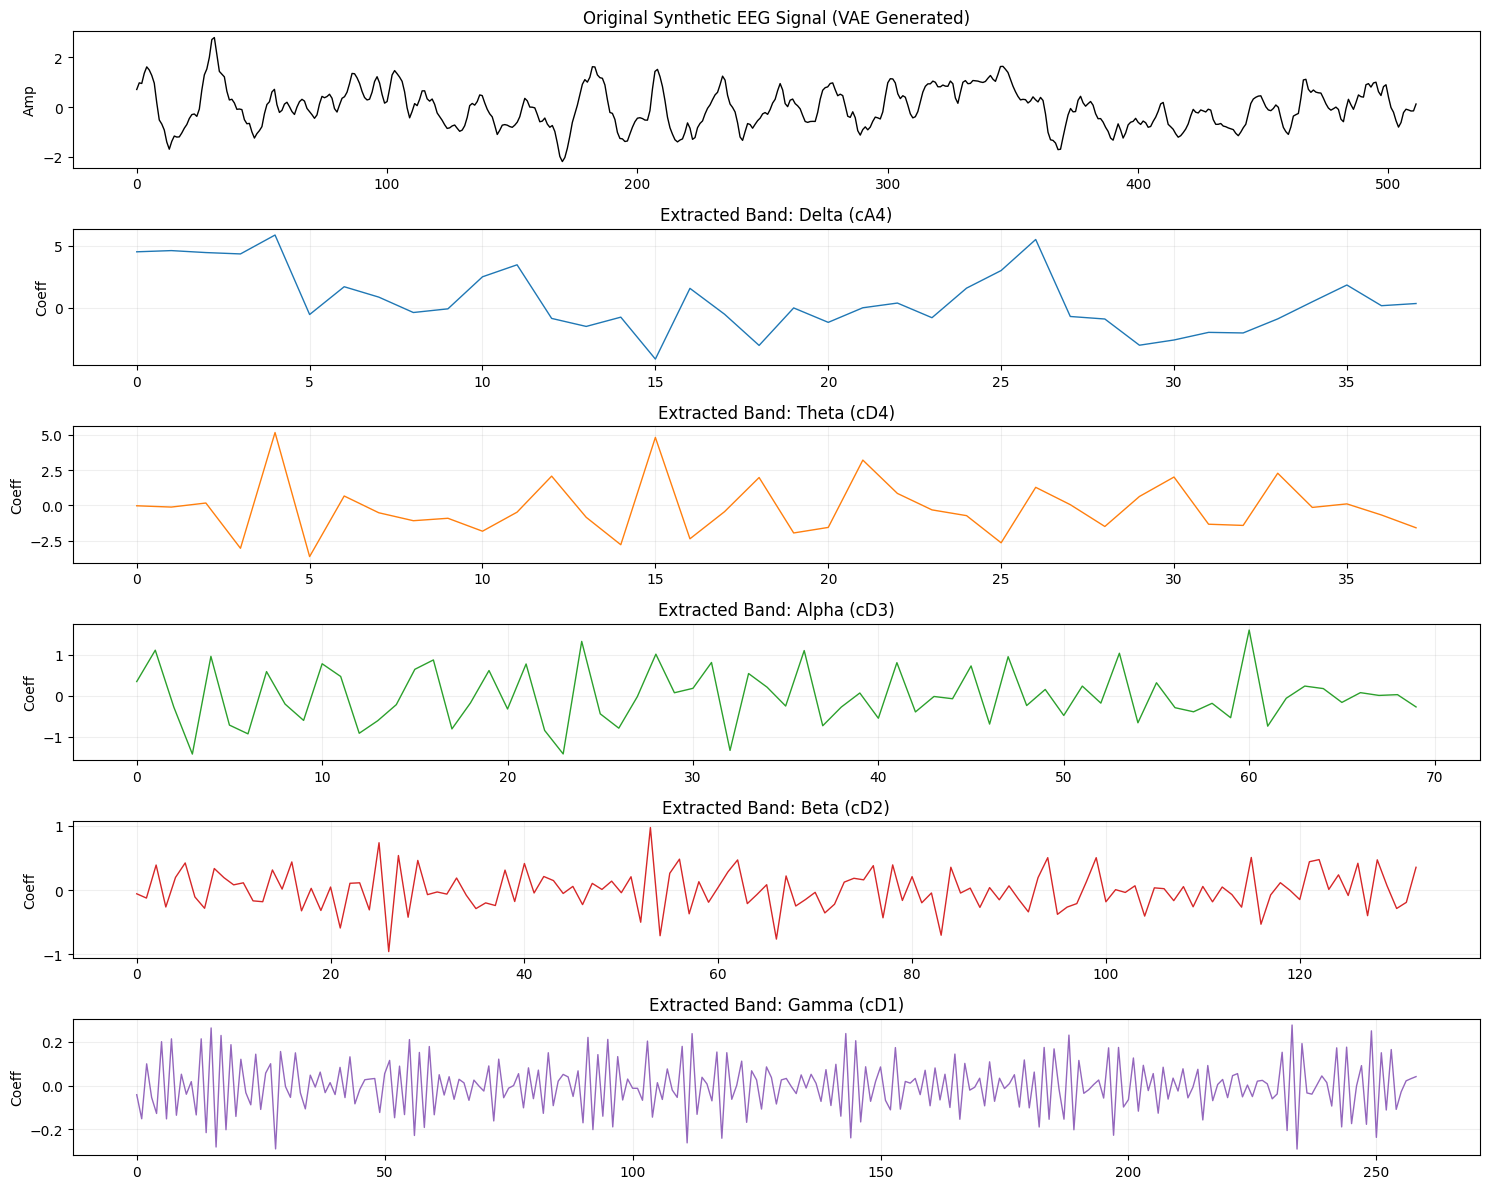

In [112]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

def plot_synthetic_bands(decoder_model, latent_dim=16):
    # 1. Generate ONE synthetic signal
    z_sample = np.random.normal(size=(1, latent_dim))
    synthetic_signal = decoder_model.predict(z_sample, verbose=0).flatten()
    
    # 2. Decompose using your pipeline's settings (db4, level 4)
    coeffs = pywt.wavedec(synthetic_signal, 'db4', level=4)
    delta, theta, alpha, beta, gamma = coeffs # Unpacking levels
    
    # 3. Visualization
    bands = ['Delta (cA4)', 'Theta (cD4)', 'Alpha (cD3)', 'Beta (cD2)', 'Gamma (cD1)']
    data = [delta, theta, alpha, beta, gamma]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    plt.figure(figsize=(15, 12))
    
    # Plot Original Synthetic Signal
    plt.subplot(6, 1, 1)
    plt.plot(synthetic_signal, color='black', linewidth=1)
    plt.title("Original Synthetic EEG Signal (VAE Generated)")
    plt.ylabel("Amp")
    
    # Plot Each Band
    for i in range(5):
        plt.subplot(6, 1, i + 2)
        plt.plot(data[i], color=colors[i], linewidth=1)
        plt.title(f"Extracted Band: {bands[i]}")
        plt.ylabel("Coeff")
        plt.grid(True, alpha=0.2)
        
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_synthetic_bands(decoder, latent_dim=16)

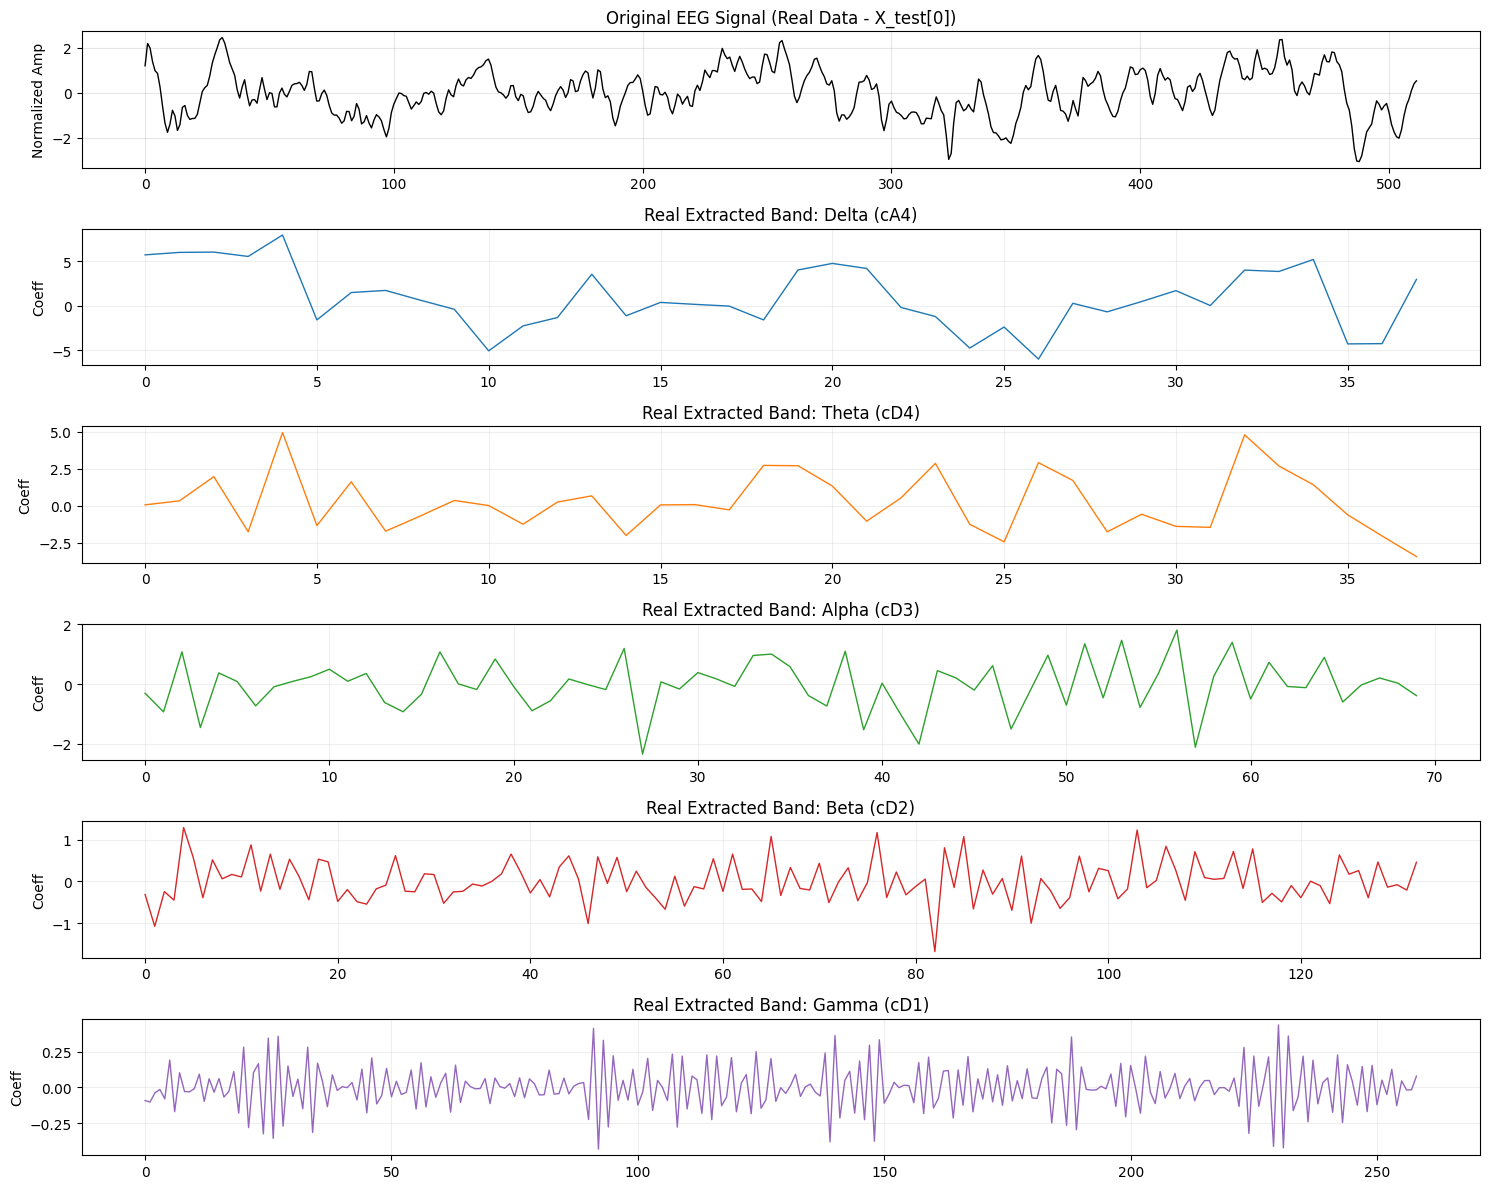

In [113]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

def plot_original_bands(signal_data, sample_index=0):
    # 1. Select the original signal from your test set
    # Ensure it is 1D (512 samples)
    original_signal = signal_data[sample_index].flatten()
    
    # 2. Decompose using your pipeline's settings (db4, level 4)
    # This matches the extraction in exp_dwt_baseline_4s_multichannel.ipynb
    coeffs = pywt.wavedec(original_signal, 'db4', level=4)
    
    # Mapping based on your DWT level logic:
    # cA4=Delta, cD4=Theta, cD3=Alpha, cD2=Beta, cD1=Gamma
    delta, theta, alpha, beta, gamma = coeffs 
    
    # 3. Visualization Setup
    bands = ['Delta (cA4)', 'Theta (cD4)', 'Alpha (cD3)', 'Beta (cD2)', 'Gamma (cD1)']
    data = [delta, theta, alpha, beta, gamma]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    plt.figure(figsize=(15, 12))
    
    # Plot Original Real Signal
    plt.subplot(6, 1, 1)
    plt.plot(original_signal, color='black', linewidth=1)
    plt.title(f"Original EEG Signal (Real Data - X_test[{sample_index}])")
    plt.ylabel("Normalized Amp")
    plt.grid(True, alpha=0.3)
    
    # Plot Each Frequency Band
    for i in range(5):
        plt.subplot(6, 1, i + 2)
        plt.plot(data[i], color=colors[i], linewidth=1)
        plt.title(f"Real Extracted Band: {bands[i]}")
        plt.ylabel("Coeff")
        plt.grid(True, alpha=0.2)
        
    plt.tight_layout()
    plt.show()

# Run for the first original signal in X_test
plot_original_bands(X_test, sample_index=0)

In [117]:
from scipy.signal import butter, filtfilt

def apply_eeg_penalty_filter(signals, cutoff=40, fs=128, order=5):
    """
    Applies a low-pass filter to penalize/remove high-frequency noise.
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Apply filter to each generated signal
    clean_signals = np.array([filtfilt(b, a, s) for s in signals])
    return clean_signals

# Apply to your synthetic batch
filtered_synthetic = apply_eeg_penalty_filter(synthetic_signals, cutoff=50)

In [115]:
from scipy.stats import wasserstein_distance

def calculate_quality_score(real_features, synth_features):
    # We use Earth Mover's Distance to see how far apart the distributions are
    scores = []
    for i in range(real_features.shape[1]):
        score = wasserstein_distance(real_features[:, i], synth_features[:, i])
        scores.append(score)
    
    avg_dist = np.mean(scores)
    print(f"Average Distribution Distance: {avg_dist:.4f}")
    return "High Quality" if avg_dist < 0.5 else "Needs Retraining"

# Compare the DWT features of 100 real vs 100 synthetic
real_ft = extract_dwt_features(X_test[:100])
synth_ft = extract_dwt_features(synthetic_signals[:100])
calculate_quality_score(real_ft, synth_ft)

Average Distribution Distance: 0.5282


'Needs Retraining'

4/4 [==============================] - 0s 35ms/step


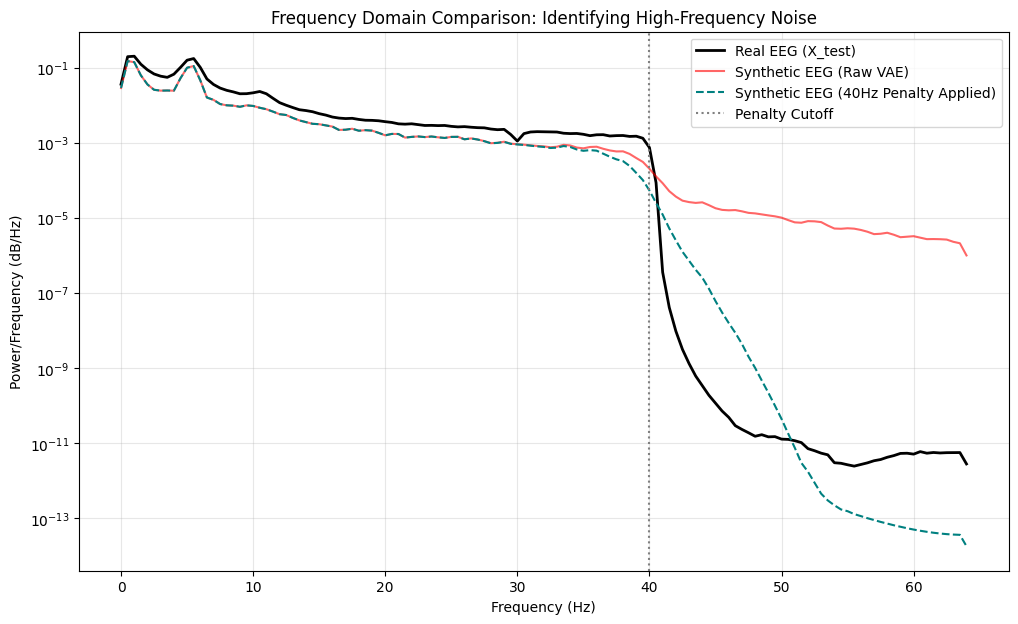

In [119]:
from scipy import signal as sig
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt

def apply_lowpass_filter(signals, cutoff=40, fs=128, order=5):
    """Applies a Butterworth low-pass filter to penalize high frequencies."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return np.array([filtfilt(b, a, s) for s in signals])

def compare_psd_with_penalty(real_signals, synth_signals, fs=128, cutoff_penalty=40):
    # 1. Apply the 'Penalty' (Low-Pass Filter) to a copy of the synthetic data
    synth_signals_filtered = apply_lowpass_filter(synth_signals, cutoff=cutoff_penalty, fs=fs)
    
    plt.figure(figsize=(12, 7))
    
    # Calculate PSD for real data
    freqs_real, psd_real = sig.welch(real_signals.reshape(-1, 512), fs, nperseg=256)
    # Calculate PSD for raw synthetic data
    freqs_synth, psd_synth = sig.welch(synth_signals.reshape(-1, 512), fs, nperseg=256)
    # Calculate PSD for filtered (penalized) synthetic data
    freqs_filt, psd_filt = sig.welch(synth_signals_filtered.reshape(-1, 512), fs, nperseg=256)
    
    # Plotting
    plt.semilogy(freqs_real, np.mean(psd_real, axis=0), label='Real EEG (X_test)', color='black', linewidth=2)
    plt.semilogy(freqs_synth, np.mean(psd_synth, axis=0), label='Synthetic EEG (Raw VAE)', color='red', alpha=0.6)
    plt.semilogy(freqs_filt, np.mean(psd_filt, axis=0), label=f'Synthetic EEG ({cutoff_penalty}Hz Penalty Applied)', color='teal', linestyle='--')
    
    plt.axvline(x=cutoff_penalty, color='gray', linestyle=':', label='Penalty Cutoff')
    
    plt.title("Frequency Domain Comparison: Identifying High-Frequency Noise")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power/Frequency (dB/Hz)")
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.show()

# --- Execution ---
# 1. Generate fresh signals from your decoder
synthetic_signals = generate_synthetic_eeg(decoder, num_samples=100, latent_dim=16)

# 2. Compare them using your function (with the added penalty visualization)
compare_psd_with_penalty(X_test, synthetic_signals, fs=128, cutoff_penalty=40)